# Data Loading

In [2]:
# Import required libraries

import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [3]:
# Read the CSV file into a DataFrame
df = pd.read_csv("datasets/coca-cola_from_dump.csv")
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,22222084941,Coca-Cola original,Coca-Cola,"beverages, carbonated-drinks, sodas, colas",spain,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
1,42111558865,coca cola zéro,"Coca-Cola-light, coca cola","beverages, carbonated-drinks, artificially-swe...",france,"plastic, bottle",NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
2,49000004632,Coca-Cola,Coca-Cola,"beverages-and-beverages-preparations, beverage...","france, united-states","bottle-or-vial, bottle",NaN,NaN,e,4.0,NaN,"CARBONATED WATER, CANE SUGAR, CARAMEL COLOR, P...",NaN,NaN
3,49000012781,Coca-Cola,Coca-Cola,NaN,united-states,NaN,NaN,NaN,unknown,4.0,NaN,"CARBONATED WATER, HIGH FRUCTOSE CORN SYRUP, CA...",11.0,39.4
4,49000024685,Original Taste Soda,Coca-Cola,"beverages-and-beverages-preparations, beverage...","france, united-states",NaN,NaN,NaN,e,4.0,NaN,caffeiedo amount/serving % daily value nutriti...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,5000112686692,NaN,Coca Cola,"beverages-and-beverages-preparations, beverage...",germany,NaN,NaN,NaN,b,NaN,NaN,"água, dióxido de carbono, sumo de lima proveni...",NaN,NaN
4985,6990871421605,Coca Cola Coca Cola,Coca Cola,Dagligvarer,denmark,NaN,NaN,NaN,unknown,4.0,NaN,"Vand, sukker, kuldioxid, farvestof (E150d), sy...",NaN,NaN
4986,5942321005454,Coke zero zero,Coca-Cola,NaN,romania,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
4987,49000056166,Cherry Float Coke Zero,Coca-Cola,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [4]:
# Display the data types of each column 

df.dtypes

code                            object
product_name                       str
brands                             str
categories_tags                    str
countries_tags                     str
packaging_tags                     str
stores                             str
purchase_places                    str
nutriscore_grade                   str
nova_group                     float64
ecoscore_grade                     str
ingredients_text                   str
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [5]:
# Display the unique values in the 'code' column
df.code.unique()

array([22222084941, 42111558865, 49000004632, ..., 5942321005454,
       49000056166, 7801610350652], shape=(4989,), dtype=object)

In [6]:
# Convert the 'code' column to float64 data type
df=df.astype({"code": "float64"})

In [7]:
# Convert the 'code' column to int64 data type
df=df.astype({"code": "int64"})

In [8]:
# Convert all non-numeric columns to object data type
df[df.select_dtypes(exclude='number').columns] = df.select_dtypes(exclude='number').astype(object)

In [9]:
# Display the unique values in the 'brands' column
df.brands.unique()

array(['Coca-Cola', 'Coca-Cola-light, coca cola', 'Coca-Cola Company',
       'Coca-Cola, Coca-Cola Original Taste', 'Coca-Cola,Coke', 'Coke',
       'Coca-Cola, Coca-Cola-light', "McDonald's, The Coca-Cola Company",
       'Minute Maid,Coca cola', 'Minute Maid, Coca-Cola',
       'BRASSERIE DE TAHITI,THE COCA COLA COMPANY',
       'HI-C,Brasserie de tahiti S.A,COCA COLA COMPAGNY',
       'BRASSERIE DE TAHITI (sous license), COCA COLA INTERNATIONAL',
       'Coca cola, HI-C, brasserie de tahiti', 'Coca Cola',
       'Coca Cola, Coca Cola Life', nan, 'Minute Maid,Coca-Cola',
       'The Coca-Cola Company,Coca-Cola', 'Coca-cola',
       "Coca-Cola, McDonald's", "Coca-Cola, Mcdonald's",
       "Coca-Cola, Coca-Cola-light, Mcdonald's",
       "Mcdonald's, Sprite, The Coca Cola Company",
       "Fanta, Mcdonald's, The Coca Cola Company", 'coca-cola',
       'Coca cola', 'COCA-COLA', 'Lagrange',
       'Brioche Pasquier, Coca Cola, Kleenex',
       'SNEMBG, The Coca Cola Company', 'Coca Cola

In [10]:
# Clean the 'brands' column by removing special characters, converting to lowercase, and replacing certain characters with spaces
import re

df['brands_clean'] = (
    df['brands']
    .fillna('')
    .str.lower()
    .str.replace(r'[-_/]', ' ', regex=True)
    .str.replace(r'[^a-z0-9,\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [11]:
# Sort the words in the 'brands_clean' column alphabetically
df['brands_clean'] = df['brands_clean'].apply(
    lambda x: ' '.join(sorted(x.split()))
)

In [12]:
# Remove duplicates and sort the words in the 'brands_clean' column alphabetically
df['brands_clean'] = (
    df['brands']
    .fillna('')
    .str.lower()
    .str.replace(r'[-_/]', ' ', regex=True)
    .str.replace(r'[^a-z0-9,\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    .apply(lambda x: ', '.join(sorted(set(i.strip() for i in x.split(',') if i.strip()))))
)

In [13]:
# Display the unique values in the 'brands_clean' column
df['brands_clean'].unique()

<ArrowStringArray>
[                                                  'coca cola',
                                  'coca cola, coca cola light',
                                           'coca cola company',
                         'coca cola, coca cola original taste',
                                             'coca cola, coke',
                                                        'coke',
                            'mcdonalds, the coca cola company',
                                      'coca cola, minute maid',
                  'brasserie de tahiti, the coca cola company',
            'brasserie de tahiti sa, coca cola compagny, hi c',
 ...
                                    'quoted coca quotcolaquot',
                                            'coca cola, slice',
                                   'coca cola, georgia coffee',
                                 'coca cola company, cocacola',
                                                        'jack',
                

In [14]:
# Split the 'brands_clean' column by commas, take the first element, and strip any leading/trailing whitespace
df['brands_clean'] = df['brands_clean'].str.split(',').str[0].str.strip()

In [15]:
# Define a mapping of brand variations to standardized brand names
mapping = {
    'cocacola': 'coca cola',
    'coca cola company': 'coca cola',
    'the coca cola company': 'coca cola',
    'coca cola co': 'coca cola',
    'coca cola original taste': 'coca cola',
    'coca cola classic': 'coca cola',
    'coca cola zero': 'coca cola',
    'diet coke': 'coke'
}

df['brands_clean'] = df['brands_clean'].replace(mapping, regex=False)

In [18]:
# Normalize the country name before filtering.
def analyze_country(country):

    country = country.lower().strip().replace("_", "-")

    data = country_df[
        country_df["countries_tags"] == country
    ]

    print(f"COUNTRY: {country.upper()}")
    # ...rest of your existing function

In [20]:
# Use fuzzy matching to further standardize brand names
from rapidfuzz import process, fuzz

unique = df['brands_clean'].dropna().unique()

mapping = {}

for name in unique:
    match, score, _ = process.extractOne(name, mapping.keys(), scorer=fuzz.token_sort_ratio) if mapping else (None, 0, None)

    if score >= 90:
        mapping[name] = mapping[match]
    else:
        mapping[name] = name

df['brands_clean'] = df['brands_clean'].map(mapping)

In [21]:
# Display the value counts of the 'brands_clean' column
df['brands_clean'].value_counts()

brands_clean
coca cola                              3951
                                        390
coca cola european partners norge a      50
coke                                     45
aquarius                                 34
                                       ... 
twisties                                  1
coca cola craftea                         1
quoted coca quotcolaquot                  1
original                                  1
nordic                                    1
Name: count, Length: 210, dtype: int64

In [22]:
# Assign the cleaned and standardized brand names to a new column 'brands'
df['brands'] = df['brands_clean']

In [23]:
# Fill missing values in the 'nutriscore_grade' column with "unknown" and check for any remaining null values
df.nutriscore_grade = df.nutriscore_grade.fillna("unknown")
df.nutriscore_grade.isnull().sum()

np.int64(0)

In [24]:
# Fill missing values in specific columns with "Unknown"
cols = [
    "categories_tags",
    "countries_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "ecoscore_grade",
    "ingredients_text"
]

df[cols] = df[cols].fillna("Unknown")

# Data Preparation

In [25]:
# Create a copy of the DataFrame for further analysis
df_clean = df.copy()

In [26]:
# Split the 'countries_tags' column by commas, explode the list into separate rows, and clean the values
country_df = df_clean.copy()
country_df["countries_tags"] = country_df["countries_tags"].str.split(",")
country_df = country_df.explode("countries_tags")
country_df["countries_tags"] = country_df["countries_tags"].str.strip().str.lower()


In [27]:
# Split the 'packaging_tags' column by commas, explode the list into separate rows, and clean the values
pack_df = df_clean.copy()
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.split(",")
pack_df = pack_df.explode("packaging_tags")
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.strip().str.lower()

In [28]:
# Split the 'categories_tags' column by commas, explode the list into separate rows, and clean the values
cat_df = df_clean.copy()
cat_df["categories_tags"] = cat_df["categories_tags"].str.split(",")
cat_df = cat_df.explode("categories_tags")
cat_df["categories_tags"] = cat_df["categories_tags"].str.strip().str.lower()

In [29]:
# Split the 'stores' column by commas, explode the list into separate rows, and clean the values
store_df = df_clean.copy()
store_df["stores"] = store_df["stores"].str.split(",")
store_df = store_df.explode("stores")
store_df["stores"] = store_df["stores"].str.strip().str.lower()

In [30]:
# Split the 'product_name' column by commas, explode the list into separate rows, and clean the values
products_df = df_clean.copy()
products_df["product_name"] = products_df["product_name"].str.split(",")
products_df = products_df.explode("product_name")
products_df["product_name"] = products_df["product_name"].str.strip().str.lower()

In [31]:
# Display the value counts of the 'brands' column
df.brands.value_counts()

brands
coca cola                              3951
                                        390
coca cola european partners norge a      50
coke                                     45
aquarius                                 34
                                       ... 
twisties                                  1
coca cola craftea                         1
quoted coca quotcolaquot                  1
original                                  1
nordic                                    1
Name: count, Length: 210, dtype: int64

In [32]:
# Display the value counts of the 'countries_tags' column
country_df.value_counts("countries_tags")

countries_tags
france            1143
united-states      584
germany            440
spain              368
united-kingdom     266
                  ... 
maldives             1
macau                1
haiti                1
latinoamérica        1
mundial              1
Name: count, Length: 148, dtype: int64

In [33]:
# Display the value counts of the 'packaging_tags' column
pack_df.value_counts("packaging_tags")

packaging_tags
unknown                           3721
plastic                            561
bottle                             321
can                                154
pet-polyethylene-terephthalate     121
                                  ... 
screw-lid-plastic-bottle             1
cun                                  1
pp-5-polypropylene                   1
azul                                 1
tetra-pack                           1
Name: count, Length: 276, dtype: int64

In [34]:
# Display the value counts of the 'categories_tags' column
cat_df.value_counts("categories_tags")

categories_tags
beverages                               2901
carbonated-drinks                       2189
sodas                                   2114
unknown                                 1954
beverages-and-beverages-preparations    1794
                                        ... 
coke zero zero                             1
peaches                                    1
pt:coca-cola                               1
he:סודה                                    1
libre de calorías                          1
Name: count, Length: 546, dtype: int64

In [35]:
# Display the value counts of the 'stores' column
store_df.value_counts("stores")

stores
unknown                4429
farmacorp                60
amarket                  54
walmart                  49
carrefour                43
                       ... 
extra danmarksplass       1
coviran                   1
farmacia cristal          1
castorama                 1
vival                     1
Name: count, Length: 253, dtype: int64

In [36]:
# Display the value counts of the 'product_name' column
products_df.value_counts("product_name")

product_name
coca cola                          433
coca-cola                          240
coca cola zero                     148
sprite                              75
coca-cola zero                      74
                                  ... 
mezzo mix cherry                     1
coca cola (zero sugar)               1
coca-cola zero sugar hương vani      1
coca cola - white peach flavor       1
coca cola original tastew            1
Name: count, Length: 2584, dtype: int64

In [37]:
# Display the number of unique products
print("Total Products :", products_df["product_name"].nunique())

Total Products : 2584


In [38]:
# Display the number of unique brands
print("Total Brands :", df["brands"].nunique())

Total Brands : 210


In [39]:
# Display the number of unique countries
print("Total Categories :", cat_df["categories_tags"].nunique())

Total Categories : 546


In [40]:
# Display the number of unique countries
print("Total Countries :", country_df["countries_tags"].nunique())

Total Countries : 148


In [41]:
# Display the number of unique packaging types
print("Total Packaging Types :", pack_df["packaging_tags"].nunique())

Total Packaging Types : 276


In [42]:
# Display the number of unique stores
print("Total Stores :", store_df["stores"].nunique())

Total Stores : 253


# Dataset Summary

In [43]:
# Create a summary DataFrame that includes the number of unique values, missing values, and data types for each column in the original DataFrame
summary = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

summary

,Unique Values,Missing Values,Data Type
code,4875,0,int64
product_name,2901,260,object
brands,210,0,str
categories_tags,784,0,object
countries_tags,396,0,object
packaging_tags,337,0,object
stores,337,0,object
purchase_places,198,0,object
nutriscore_grade,7,0,object
nova_group,4,3084,float64


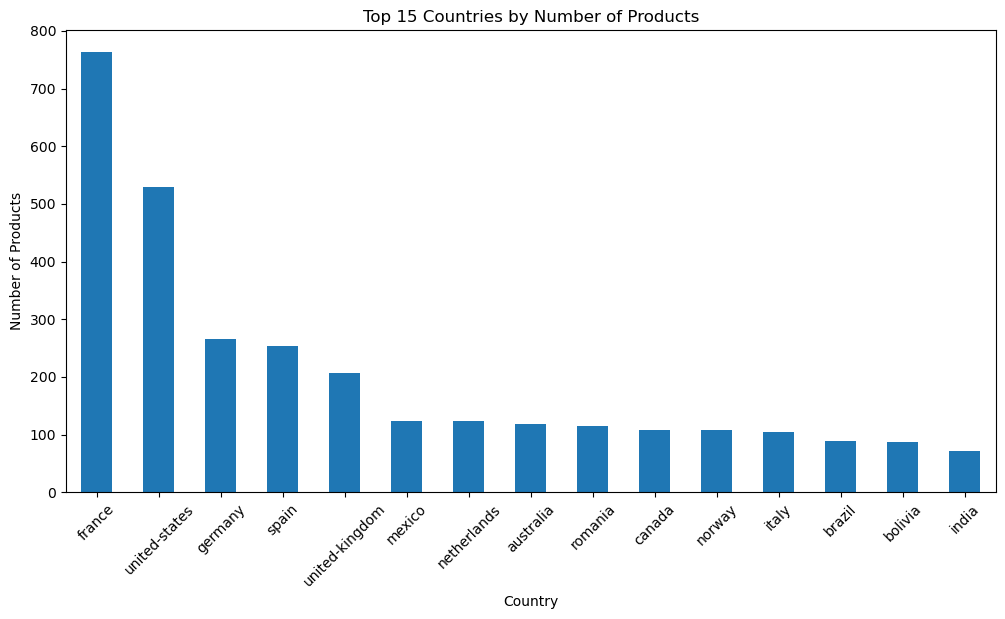

In [44]:
# Create a bar plot of the top 15 countries by number of products
import matplotlib.pyplot as plt

country = df['countries_tags'].value_counts().head(15)

plt.figure(figsize=(12,6))
country.plot(kind='bar')
plt.title('Top 15 Countries by Number of Products')
plt.xlabel('Country')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

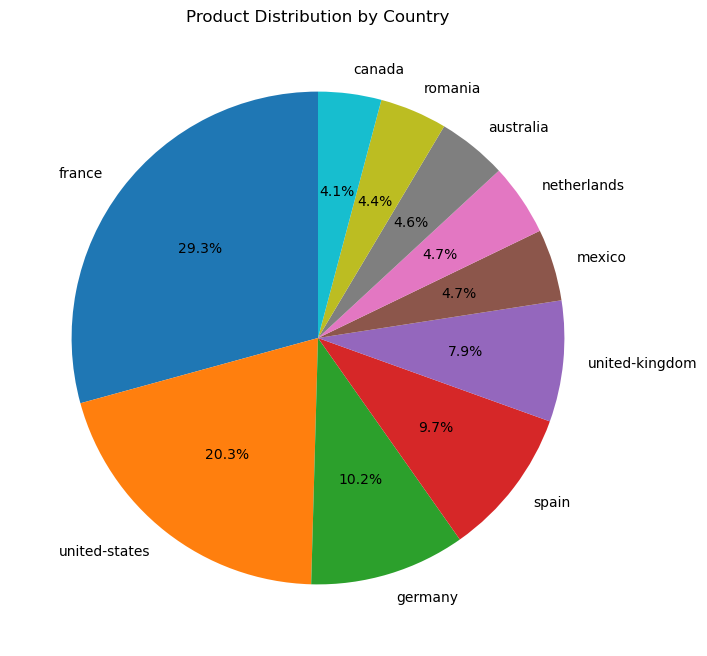

In [45]:
# Create a pie chart of the top 10 countries by number of products
top10 = df['countries_tags'].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(top10,
        labels=top10.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Product Distribution by Country')
plt.show()

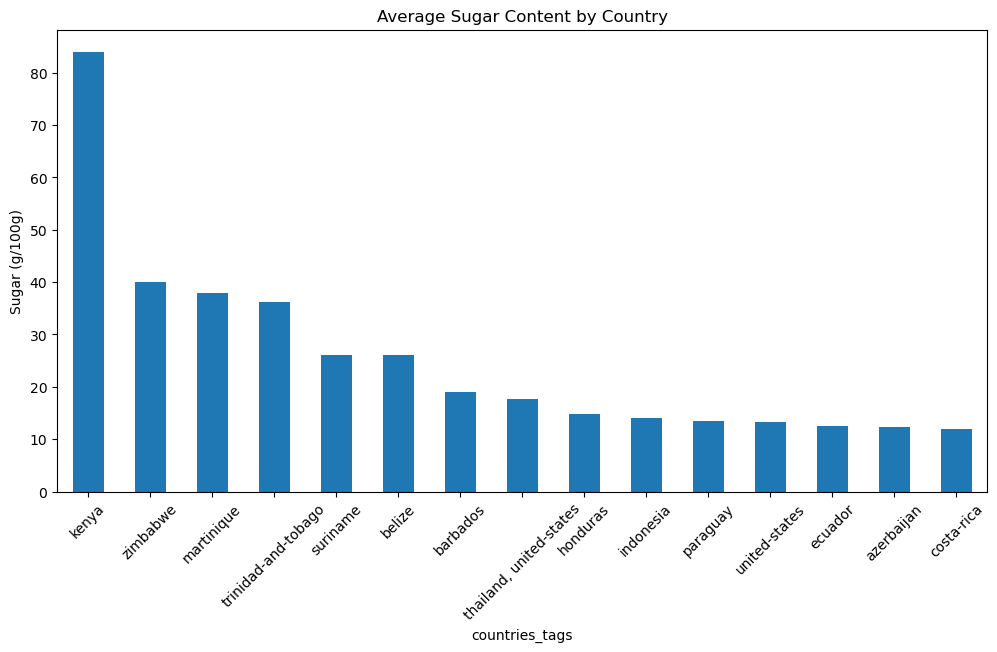

In [46]:
# Create a bar plot of the average sugar content by country
country_sugar = (
    df.groupby('countries_tags')['nutriments.sugars_100g']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
country_sugar.plot(kind='bar')
plt.title('Average Sugar Content by Country')
plt.ylabel('Sugar (g/100g)')
plt.xticks(rotation=45)
plt.show()

In [47]:
# Display the unique values in the 'countries_tags' column
df.countries_tags.unique()

array(['spain', 'france', 'france, united-states', 'united-states',
       'canada, france, united-states', 'saint-pierre-and-miquelon',
       'canada', 'french-polynesia', 'france, french-polynesia',
       'democratic-republic-of-the-congo',
       'united-kingdom, united-states', 'canada, france', 'france, india',
       'Unknown', 'ireland', 'switzerland', 'france, switzerland',
       'belgium, france, germany, morocco, switzerland',
       'france, united-kingdom', 'france, reunion',
       'france, guadeloupe, martinique',
       'france, french-guiana, guadeloupe, martinique',
       'france, martinique', 'france, french-guiana',
       'belgium, france, guadeloupe, martinique, switzerland',
       'french-guiana', 'france, martinique, switzerland',
       'france, new-caledonia', 'italy',
       'france, germany, portugal, spain', 'germany', 'russia, ukraine',
       'morocco', 'france, italy', 'czech-republic, france',
       'france, germany, italy, morocco, north-macedonia

In [48]:
# Display the duplicate rows in the 'countries_tags' column
duplicates = df[df.duplicated(subset=['countries_tags'], keep=False)]

In [49]:
# Display the number of unique values in the 'countries_tags' column
df.countries_tags.nunique()

396

In [50]:
# Display the top 15 countries by number of products
country_df["countries_tags"].head(15)

0             spain
1            france
2            france
2     united-states
3     united-states
4            france
4     united-states
5     united-states
6     united-states
7     united-states
8            france
8     united-states
9     united-states
10           france
10    united-states
Name: countries_tags, dtype: str

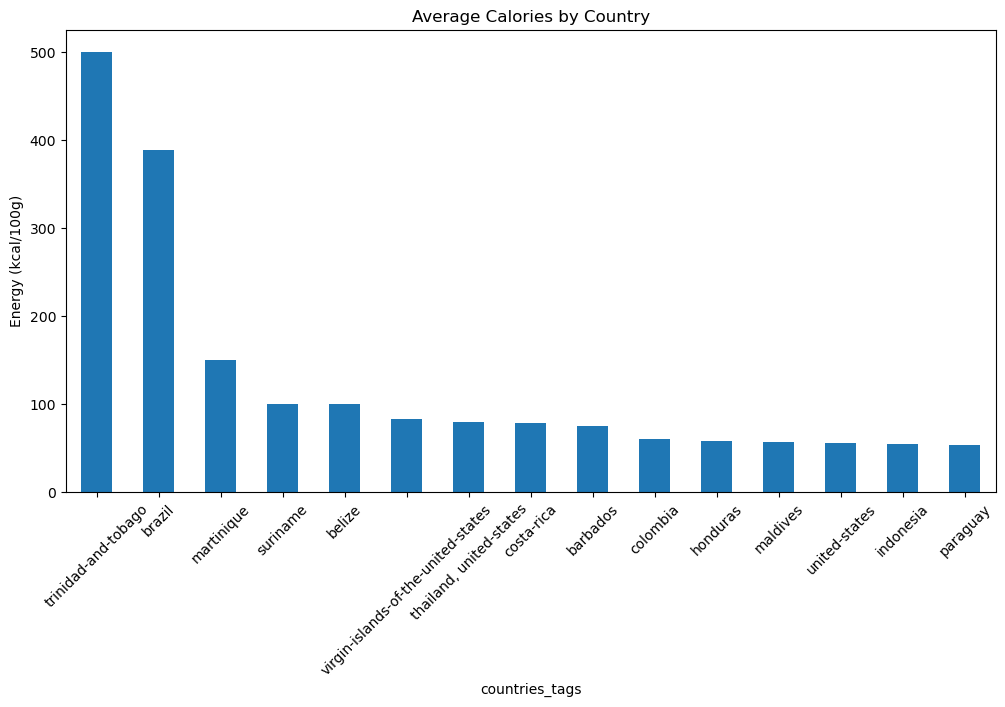

In [51]:
# Create a bar plot of the average energy content by country
country_energy = (
    df.groupby('countries_tags')['nutriments.energy-kcal_100g']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
country_energy.plot(kind='bar')
plt.title('Average Calories by Country')
plt.ylabel('Energy (kcal/100g)')
plt.xticks(rotation=45)
plt.show()

In [52]:
# Display the unique values in the 'countries_tags' column
df['countries_tags'].unique()

array(['spain', 'france', 'france, united-states', 'united-states',
       'canada, france, united-states', 'saint-pierre-and-miquelon',
       'canada', 'french-polynesia', 'france, french-polynesia',
       'democratic-republic-of-the-congo',
       'united-kingdom, united-states', 'canada, france', 'france, india',
       'Unknown', 'ireland', 'switzerland', 'france, switzerland',
       'belgium, france, germany, morocco, switzerland',
       'france, united-kingdom', 'france, reunion',
       'france, guadeloupe, martinique',
       'france, french-guiana, guadeloupe, martinique',
       'france, martinique', 'france, french-guiana',
       'belgium, france, guadeloupe, martinique, switzerland',
       'french-guiana', 'france, martinique, switzerland',
       'france, new-caledonia', 'italy',
       'france, germany, portugal, spain', 'germany', 'russia, ukraine',
       'morocco', 'france, italy', 'czech-republic, france',
       'france, germany, italy, morocco, north-macedonia

In [53]:
# Display the number of unique values in the 'countries_tags' column
len(df['countries_tags'].unique())

396

In [54]:
# Display the number of unique values in the 'countries_tags' column
df['countries_tags'].nunique()

396

# Lets Analyze one column at a time


In [55]:
# Display the summary statistics of the 'brands' column
print(df["brands"].describe())

df["brands"].value_counts()

count          4989
unique          210
top       coca cola
freq           3951
Name: brands, dtype: object


brands
coca cola                              3951
                                        390
coca cola european partners norge a      50
coke                                     45
aquarius                                 34
                                       ... 
twisties                                  1
coca cola craftea                         1
quoted coca quotcolaquot                  1
original                                  1
nordic                                    1
Name: count, Length: 210, dtype: int64

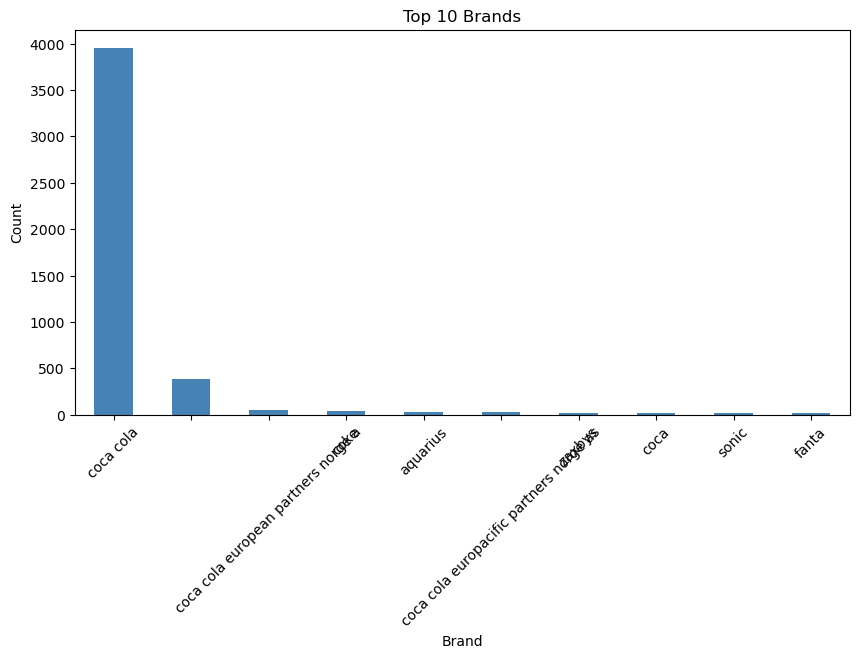

In [56]:
# Create a bar plot of the top 10 brands by number of products
plt.figure(figsize=(10,5))

df["brands"].value_counts().head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [57]:
# Display the value counts of the 'categories_tags' column
cat_df["categories_tags"].value_counts().head(15)

categories_tags
beverages                               2901
carbonated-drinks                       2189
sodas                                   2114
unknown                                 1954
beverages-and-beverages-preparations    1794
colas                                   1512
artificially-sweetened-beverages        1000
sweetened-beverages                      916
diet-beverages                           733
diet-sodas                               704
diet-cola-soft-drink                     548
plant-based-foods-and-beverages          294
plant-based-beverages                    286
non-alcoholic-beverages                  237
fruit-based-beverages                    231
Name: count, dtype: int64

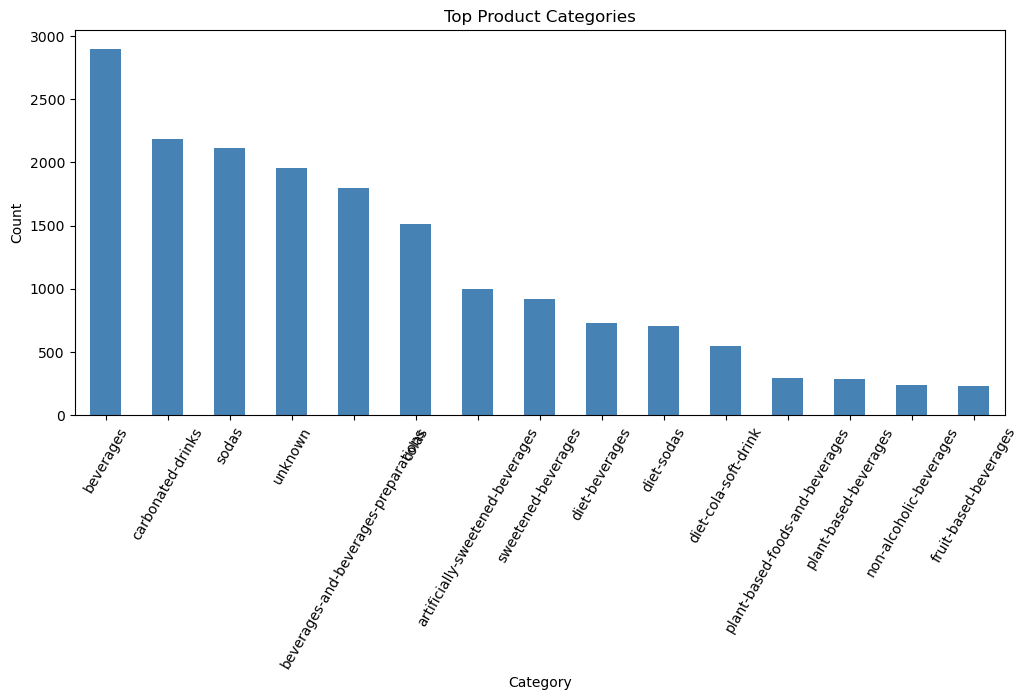

In [58]:
# Create a bar plot of the top 15 product categories by number of products
plt.figure(figsize=(12,5))

cat_df["categories_tags"].value_counts().head(15).plot(
    kind="bar",
    color=("steelblue")
)

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=60)

plt.show()

In [59]:
# Display the top 15 countries by number of products
country_df["countries_tags"].value_counts().head(15)

countries_tags
france            1143
united-states      584
germany            440
spain              368
united-kingdom     266
belgium            185
italy              155
mexico             144
romania            142
netherlands        137
australia          130
switzerland        120
canada             118
norway             118
bolivia             96
Name: count, dtype: int64

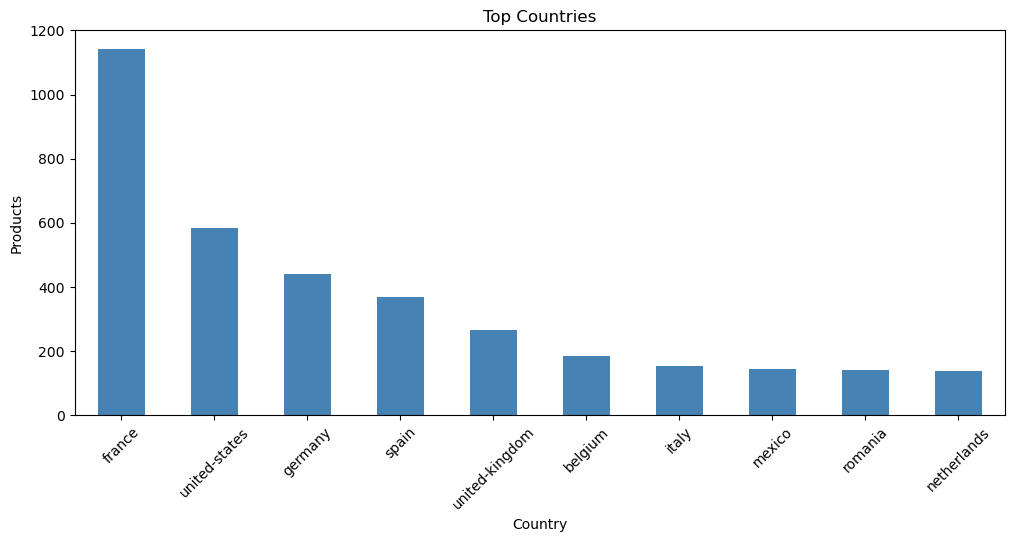

In [60]:
# Create a bar plot of the top 10 countries by number of products
plt.figure(figsize=(12,5))

country_df["countries_tags"].value_counts().head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top Countries")
plt.xlabel("Country")
plt.ylabel("Products")

plt.xticks(rotation=45)

plt.show()

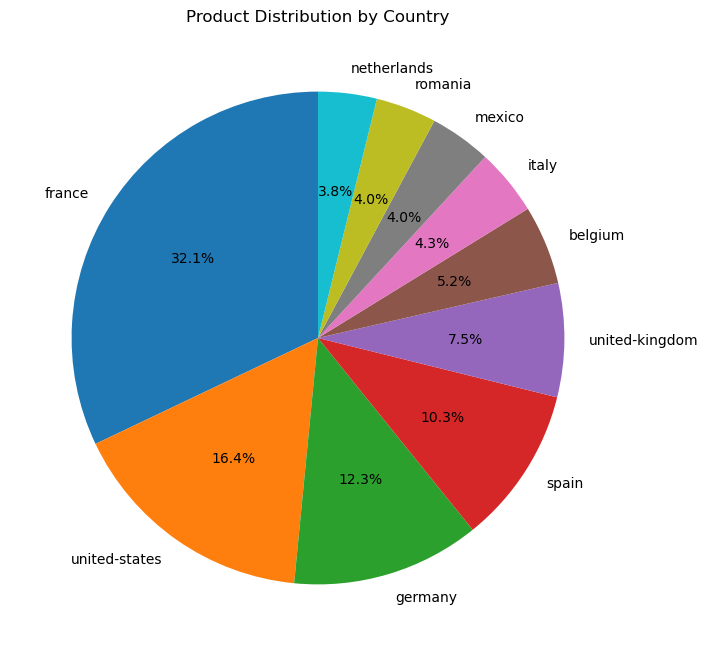

In [61]:
# Create a pie chart of the top 10 countries by number of products
top10 = country_df["countries_tags"].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top10,
    labels=top10.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Product Distribution by Country")

plt.show()

In [62]:
# Display the value counts of the 'packaging_tags' column
pack_df["packaging_tags"].value_counts().head(15)

packaging_tags
unknown                           3721
plastic                            561
bottle                             321
can                                154
pet-polyethylene-terephthalate     121
metal                               95
drink-can                           91
recyclable-metals                   67
aluminium                           67
pet-bottle                          57
glass                               53
bottle-or-vial                      43
transparent-pet                     39
aluminium-can                       37
it:bottiglia-pet                    37
Name: count, dtype: int64

In [63]:
# Create a bar plot of the top 10 packaging types by number of products
store_df["stores"].value_counts().head(15)

stores
unknown         4429
farmacorp         60
amarket           54
walmart           49
carrefour         43
soriana           43
fidalga           41
fsa               34
oxxo              32
hipermaxi         30
coles             28
woolworths        26
la comer          25
carrefour.fr      24
sams club         22
Name: count, dtype: int64

In [64]:
# Create a bar plot of the top 10 stores by number of products
df["purchase_places"].value_counts().head(15)

purchase_places
Unknown                   4449
Cochabamba,Bolivia          70
France                      38
Walmart                     35
Calgary,Alberta,Canada      22
Deutschland                 14
México                      12
Bolivia                     12
España                       9
Bergen,Norway                9
Courrières,France            8
United Kingdom               8
NSW,Australia                8
Paris,France                 7
Sweden                       7
Name: count, dtype: int64

In [65]:
# Display the value counts of the 'ecoscore_grade' column
df["ecoscore_grade"].value_counts()

ecoscore_grade
Unknown           4249
unknown            478
not-applicable     229
c                   12
d                    8
a                    7
e                    4
a-plus               1
b                    1
Name: count, dtype: int64

In [66]:
# Create country-level dataframe
country_df = df.copy()

# Split multiple countries
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .fillna("")
    .str.split(",")
)

country_df = country_df.explode("countries_tags")

# Clean country names
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .str.strip()
    .str.lower()
)

# Remove empty countries
country_df = country_df[
    country_df["countries_tags"] != ""
]

country_df.head()

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g,brands_clean
0,22222084941,Coca-Cola original,coca cola,"beverages, carbonated-drinks, sodas, colas",spain,Unknown,Unknown,Unknown,unknown,NaN,Unknown,Unknown,NaN,NaN,coca cola
1,42111558865,coca cola zéro,coca cola,"beverages, carbonated-drinks, artificially-swe...",france,"plastic, bottle",Unknown,Unknown,unknown,NaN,Unknown,Unknown,NaN,NaN,coca cola
2,49000004632,Coca-Cola,coca cola,"beverages-and-beverages-preparations, beverage...",france,"bottle-or-vial, bottle",Unknown,Unknown,e,4.0,Unknown,"CARBONATED WATER, CANE SUGAR, CARAMEL COLOR, P...",NaN,NaN,coca cola
2,49000004632,Coca-Cola,coca cola,"beverages-and-beverages-preparations, beverage...",united-states,"bottle-or-vial, bottle",Unknown,Unknown,e,4.0,Unknown,"CARBONATED WATER, CANE SUGAR, CARAMEL COLOR, P...",NaN,NaN,coca cola
3,49000012781,Coca-Cola,coca cola,Unknown,united-states,Unknown,Unknown,Unknown,unknown,4.0,Unknown,"CARBONATED WATER, HIGH FRUCTOSE CORN SYRUP, CA...",11.0,39.4,coca cola


In [67]:
# Display the number of unique products by country
country_product_count = (
    country_df.groupby("countries_tags")["code"]
    .nunique()
    .sort_values(ascending=False)
)

country_product_count.head(20)

countries_tags
france            1143
united-states      472
germany            440
spain              368
united-kingdom     266
belgium            185
italy              155
mexico             144
romania            142
netherlands        137
australia          130
switzerland        120
canada             118
norway             118
bolivia             96
brazil              90
india               82
ireland             70
morocco             66
poland              65
Name: code, dtype: int64

In [68]:
# Create a summary DataFrame that includes the number of unique products, average calories, and average sugar content for each country
country_nutrition = (
    country_df.groupby("countries_tags")
    .agg(
        Products=("code", "nunique"),
        Avg_Calories=("nutriments.energy-kcal_100g", "mean"),
        Avg_Sugar=("nutriments.sugars_100g", "mean")
    )
    .reset_index()
)

country_nutrition = country_nutrition.sort_values(
    "Products",
    ascending=False
)

country_nutrition.head(20)

,countries_tags,Products,Avg_Calories,Avg_Sugar
43,france,1143,NaN,NaN
139,united-states,472,55.329789,13.125858
47,germany,440,NaN,NaN
122,spain,368,NaN,NaN
138,united-kingdom,266,NaN,NaN
11,belgium,185,NaN,NaN
65,italy,155,NaN,NaN
83,mexico,144,NaN,NaN
109,romania,142,18.092593,5.116389
91,netherlands,137,11.385000,2.221053


In [69]:
# Reset index
country_df = country_df.reset_index(drop=True)

# Remove missing nutrition grades
nutrition_data = country_df.dropna(
    subset=["nutriscore_grade"]
).copy()

# Remove empty country names
nutrition_data = nutrition_data[
    nutrition_data["countries_tags"].notna() &
    (nutrition_data["countries_tags"] != "")
]

# Country-wise Nutrition Score distribution
nutrition_by_country = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"]
)

nutrition_by_country

nutriscore_grade,a,b,c,d,e,not-applicable,unknown
countries_tags,,,,,,,
albania,0,0,0,0,4,0,1
algeria,0,2,3,3,9,0,21
andorra,0,0,1,2,0,0,0
argentina,0,2,15,7,7,0,32
armenia,0,0,0,0,1,0,2
...,...,...,...,...,...,...,...
venezuela,1,0,2,0,1,0,4
vietnam,0,1,0,2,3,0,10
virgin-islands-of-the-united-states,0,0,1,0,1,0,0


In [70]:
# Create a percentage distribution of nutrition scores by country
nutrition_percentage = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"],
    normalize="index"
) * 100

nutrition_percentage = nutrition_percentage.round(2)

nutrition_percentage.head(20)

nutriscore_grade,a,b,c,d,e,not-applicable,unknown
countries_tags,,,,,,,
albania,0.00,0.00,0.00,0.00,80.00,0.00,20.00
algeria,0.00,5.26,7.89,7.89,23.68,0.00,55.26
andorra,0.00,0.00,33.33,66.67,0.00,0.00,0.00
argentina,0.00,3.17,23.81,11.11,11.11,0.00,50.79
armenia,0.00,0.00,0.00,0.00,33.33,0.00,66.67
australia,2.31,3.85,10.77,2.31,14.62,0.00,66.15
austria,3.28,8.20,18.03,6.56,29.51,1.64,32.79
azerbaijan,0.00,0.00,20.00,0.00,60.00,0.00,20.00
bangladesh,0.00,0.00,0.00,0.00,27.27,0.00,72.73


In [71]:
# Create a bar plot of the average sugar content by country
sugar_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.sugars_100g"]
    .mean()
    .sort_values(ascending=False)
)

sugar_by_country.head(20)

countries_tags
kenya                  84.000000
zimbabwe               40.000000
martinique             38.000000
trinidad-and-tobago    36.100000
suriname               26.000000
belize                 26.000000
barbados               19.000000
honduras               14.840000
indonesia              14.100000
paraguay               13.500000
united-states          13.125858
ecuador                12.500000
azerbaijan             12.400000
costa-rica             11.893333
bangladesh             11.860000
saudi-arabia           11.800000
uruguay                11.000000
saint-martin           11.000000
world                  10.796429
russia                 10.600000
Name: nutriments.sugars_100g, dtype: float64

In [72]:
# Create a bar plot of the average energy content by country
calories_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.energy-kcal_100g"]
    .mean()
    .sort_values(ascending=False)
)

calories_by_country.head(20)

countries_tags
trinidad-and-tobago                    500.000000
brazil                                 389.000000
martinique                             150.000000
belize                                 100.000000
suriname                               100.000000
virgin-islands-of-the-united-states     83.100000
costa-rica                              78.170000
barbados                                75.000000
colombia                                59.927433
honduras                                57.600000
maldives                                56.840000
united-states                           55.329789
indonesia                               55.000000
paraguay                                54.000000
azerbaijan                              52.000000
bangladesh                              50.000000
ecuador                                 48.862500
tanzania                                47.000000
saudi-arabia                            47.000000
venezuela                          

In [73]:
# Create a percentage distribution of ecoscore grades by country
eco_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["ecoscore_grade"],
    normalize="index"
) * 100

eco_by_country.round(2).head(20)

ecoscore_grade,Unknown,a,a-plus,b,c,d,e,not-applicable,unknown
countries_tags,,,,,,,,,
albania,100.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.00
algeria,89.47,2.63,0.0,0.00,0.0,0.00,0.0,5.26,2.63
andorra,100.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.00
argentina,65.08,0.00,0.0,1.59,0.0,1.59,0.0,15.87,15.87
armenia,100.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.00
australia,66.15,0.00,0.0,0.00,0.0,0.00,0.0,14.62,19.23
austria,95.08,0.00,0.0,0.00,0.0,0.00,0.0,1.64,3.28
azerbaijan,100.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.00
bangladesh,90.91,0.00,0.0,0.00,0.0,0.00,0.0,9.09,0.00


In [74]:
# Create a percentage distribution of NOVA groups by country
nova_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["nova_group"],
    normalize="index"
) * 100

nova_by_country.round(2).head(20)

nova_group,1.0,2.0,3.0,4.0
countries_tags,,,,
albania,0.00,0.0,0.00,100.00
algeria,0.00,0.0,0.00,100.00
andorra,33.33,0.0,0.00,66.67
argentina,5.71,0.0,0.00,94.29
armenia,0.00,0.0,0.00,100.00
australia,2.94,0.0,1.47,95.59
austria,5.13,0.0,2.56,92.31
azerbaijan,0.00,0.0,0.00,100.00
bangladesh,0.00,0.0,0.00,100.00


In [75]:
# Define a function to analyze a specific country
def analyze_country(country):

    data = country_df[
        country_df["countries_tags"] == country.lower()
    ]

    print(f"COUNTRY: {country.upper()}")
    print("=" * 50)

    print(f"Products: {data['code'].nunique()}")

    print(
        f"Average Calories: "
        f"{data['nutriments.energy-kcal_100g'].mean():.2f} kcal/100g"
    )

    print(
        f"Average Sugar: "
        f"{data['nutriments.sugars_100g'].mean():.2f} g/100g"
    )

    print("\nNutrition Score Distribution:")
    print(
        data["nutriscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nNOVA Distribution:")
    print(
        data["nova_group"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nEcoScore Distribution:")
    print(
        data["ecoscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

In [76]:
# Analyze France
analyze_country("france")

COUNTRY: FRANCE
Products: 1143
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown           40.86
e                 25.37
c                 19.51
b                  8.92
d                  4.72
not-applicable     0.35
a                  0.26
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    96.21
1.0     2.46
3.0     0.95
2.0     0.38
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [77]:
# Analyze germany
analyze_country("germany")

COUNTRY: GERMANY
Products: 440
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown           37.50
c                 23.41
e                 21.36
d                  9.55
b                  5.23
a                  2.27
not-applicable     0.68
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    95.40
1.0     3.83
3.0     0.77
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [78]:
# Analyze spain
analyze_country("spain")

COUNTRY: SPAIN
Products: 368
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    62.23
c          16.30
e           8.97
b           6.25
d           5.16
a           1.09
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    94.21
1.0     4.96
3.0     0.83
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [79]:
# Analyze belgium
analyze_country("belgium")

COUNTRY: BELGIUM
Products: 185
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    32.97
c          28.11
e          23.78
b           9.19
d           5.95
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [80]:
# Analyze Italy
analyze_country("Italy")

COUNTRY: ITALY
Products: 155
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    56.77
e          18.06
c          16.77
b           5.81
d           2.58
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [81]:
# Analyze belgium
analyze_country("belgium")

COUNTRY: BELGIUM
Products: 185
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    32.97
c          28.11
e          23.78
b           9.19
d           5.95
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    100.0
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [82]:
# Analyze mexico
analyze_country("mexico")

COUNTRY: MEXICO
Products: 144
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown           36.81
e                 30.56
c                 11.11
b                  9.72
d                  9.03
a                  2.08
not-applicable     0.69
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    65.93
3.0    23.08
1.0    10.99
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown           93.75
unknown            4.86
not-applicable     1.39
Name: proportion, dtype: float64


In [83]:
# Analyze romania
analyze_country("romania")

COUNTRY: ROMANIA
Products: 142
Average Calories: 18.09 kcal/100g
Average Sugar: 5.12 g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    35.92
c          21.83
e          21.83
d           9.86
b           8.45
a           2.11
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    96.77
1.0     2.15
3.0     1.08
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown           78.17
not-applicable    14.08
unknown            6.34
e                  0.70
c                  0.70
Name: proportion, dtype: float64


In [84]:
# Analyze Netherlands
analyze_country("netherlands")

COUNTRY: NETHERLANDS
Products: 137
Average Calories: 11.38 kcal/100g
Average Sugar: 2.22 g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    68.61
c          13.14
e          10.95
b           7.30
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    97.73
1.0     1.14
3.0     1.14
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown           89.78
not-applicable     9.49
unknown            0.73
Name: proportion, dtype: float64


ERROR! Session/line number was not unique in database. History logging moved to new session 46


In [85]:
# Analyze spain
analyze_country("spain")

COUNTRY: SPAIN
Products: 368
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    62.23
c          16.30
e           8.97
b           6.25
d           5.16
a           1.09
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    94.21
1.0     4.96
3.0     0.83
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown    100.0
Name: proportion, dtype: float64


In [87]:
analyze_country("united-states")

COUNTRY: UNITED-STATES
Products: 472
Average Calories: 55.33 kcal/100g
Average Sugar: 13.13 g/100g

Nutrition Score Distribution:
nutriscore_grade
unknown    53.77
e          17.64
b          16.44
c          10.79
d           1.03
a           0.34
Name: proportion, dtype: float64

NOVA Distribution:
nova_group
4.0    94.56
1.0     3.40
3.0     2.04
Name: proportion, dtype: float64

EcoScore Distribution:
ecoscore_grade
Unknown           72.77
unknown           23.12
not-applicable     3.60
a                  0.34
c                  0.17
Name: proportion, dtype: float64


# Observations

In [ ]:
# The dataset is diverse, with France, United States, and Germany having the highest number of products.
# Packaging and store information contains substantial missing/unknown values, limiting detailed analysis.
# EcoScore data is also highly incomplete, with a large proportion classified as unknown.
# Among countries with available nutrition data, Kenya has the highest average sugar, while Trinidad and Tobago has the highest average energy.
# NOVA Group 4 dominates across many countries, showing a high presence of highly processed products.
# Overall, the dataset provides useful country-wise, nutritional, and product-level insights, but missing values and inconsistent country naming reduce the reliability of some comparisons.